In [2]:
import numpy as np
import torch
import torch.nn as nn
from accelerate import init_empty_weights
from accelerate.utils.modeling import find_tied_parameters, get_mixed_precision_context_manager
from accelerate.utils.operations import convert_outputs_to_fp32
from bitsandbytes.nn import Linear8bitLt, Linear4bit, LinearFP4, LinearNF4
from collections import Counter
from transformers import AutoModelForCausalLM, BitsAndBytesConfig, AutoTokenizer, AutoConfig
# In Transformers v5.0, the function got moved to a different module
from transformers.quantizers.base import get_keys_to_not_convert
# from transformers.integrations.bitsandbytes import get_keys_to_not_convert
from types import MethodType
from matplotlib import pyplot as plt

/home/ankitanand/Documents/pp/Finetuning_HF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# num_parms = 360 # 36M parameters
# bits_per_parm = 16
# model_size_in_mb = (num_parms * (bits_per_parm / 8)) / 1e6
# model_size_in_mb 

In [4]:
torch.manual_seed(11)
weights = torch.randn(1000) * .07
weights.min(), weights.max()

(tensor(-0.2066), tensor(0.2097))

In [5]:
n_bins = 4
bins = torch.linspace(weights.min(), weights.max(), n_bins+1)
bin_width = bins[1]-bins[0]
bins, bin_width

(tensor([-0.2066, -0.1026,  0.0015,  0.1056,  0.2097]), tensor(0.1041))

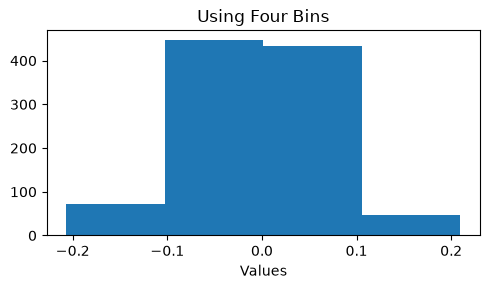

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
counts, _, _ = ax.hist(weights, bins=bins)
ax.set_xlabel('Values')
ax.set_title('Using Four Bins')
fig.tight_layout()

In [7]:
bin_indexes = (weights.view(-1, 1) > bins).to(torch.int).argmin(dim=1) - 1
print(weights[:20])
print(bin_indexes[:20])

tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048,  0.0099, -0.0367,
        -0.0174, -0.0368,  0.2025, -0.0416,  0.0918,  0.0247, -0.0921, -0.0006,
         0.0174,  0.1101, -0.1148, -0.1115])
tensor([1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 3, 1, 2, 2, 1, 1, 2, 3, 0, 0])


In [8]:
bin_values = bins[:-1]
first_bin = bin_values[0]
bin_values

tensor([-0.2066, -0.1026,  0.0015,  0.1056])

In [9]:
torch.arange(0, n_bins) * bin_width + first_bin

tensor([-0.2066, -0.1026,  0.0015,  0.1056])

In [10]:
approx_values = bin_indexes * bin_width + first_bin
print(approx_values[:20])

tensor([-0.1026,  0.0015, -0.1026,  0.0015, -0.1026, -0.2066,  0.0015, -0.1026,
        -0.1026, -0.1026,  0.1056, -0.1026,  0.0015,  0.0015, -0.1026, -0.1026,
         0.0015,  0.1056, -0.2066, -0.2066])


In [11]:
print(weights[:20])

tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048,  0.0099, -0.0367,
        -0.0174, -0.0368,  0.2025, -0.0416,  0.0918,  0.0247, -0.0921, -0.0006,
         0.0174,  0.1101, -0.1148, -0.1115])


In [12]:
mse_fn = nn.MSELoss()
mse_fn(approx_values, weights).sqrt()

tensor(0.0615)

In [13]:
def quantize(weights, n_bits=8):
    assert n_bits <= 16, "Using more bits may very slow execution and/or crashing."
    n_bins = 2**n_bits
    bins = torch.linspace(weights.min(), weights.max(), n_bins+1)
    first_bin = bins[0]
    bin_width = bins[1]-bins[0]
    bin_indexes = (weights.view(-1, 1) > bins).to(torch.int).argmin(dim=1) - 1
    return bin_indexes, bin_width, first_bin

def dequantize(bin_indexes, bin_width, first_bin):
    approx_values = bin_indexes * bin_width + first_bin
    return approx_values

In [14]:
for n_bits in [2, 4, 8, 16]:
    res = quantize(weights, n_bits=n_bits)
    approx_values = dequantize(*res)
    print(f'{n_bits}-bit Quantization:')
    print(approx_values[:6])
    print(weights[:6])
    print(mse_fn(approx_values, weights).sqrt())
    print('\n')

2-bit Quantization:
tensor([-0.1026,  0.0015, -0.1026,  0.0015, -0.1026, -0.2066])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0615)


4-bit Quantization:
tensor([-0.0505,  0.0535, -0.0505,  0.0015, -0.0245, -0.1286])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0152)


8-bit Quantization:
tensor([-0.0359,  0.0714, -0.0261,  0.0080, -0.0131, -0.1058])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0010)


16-bit Quantization:
tensor([-0.0359,  0.0718, -0.0248,  0.0085, -0.0128, -0.1049])
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])
tensor(0.0001)




In [15]:
fp16_weights = weights.to(torch.float16)
print(fp16_weights[:6])
print(weights[:6])

tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048],
       dtype=torch.float16)
tensor([-0.0358,  0.0720, -0.0247,  0.0086, -0.0127, -0.1048])


In [16]:
print(mse_fn(fp16_weights, weights).sqrt())

tensor(1.4244e-05)


In [17]:
torch.manual_seed(14)
tiny_values = torch.randn(1000)*1e-5
fp16_tiny_values = tiny_values.to(torch.float16)
mse_fn(fp16_tiny_values, tiny_values)

tensor(2.8527e-16)

In [18]:
print(tiny_values[155:160])
print(fp16_tiny_values[155:160])

tensor([-2.7241e-06,  1.1441e-05,  3.7199e-06, -1.1252e-06, -2.4735e-08])
tensor([-2.7418e-06,  1.1444e-05,  3.6955e-06, -1.1325e-06, -0.0000e+00],
       dtype=torch.float16)


In [19]:
torch.manual_seed(19)
large_values = torch.randn(1000)*1e5
fp16_large_values = large_values.to(torch.float16)
print(large_values[:5])
print(fp16_large_values[:5])

tensor([155074.0938,  64881.6602,   2729.6060, -40790.6602,  68846.7188])
tensor([    inf,  64896.,   2730., -40800.,     inf], dtype=torch.float16)


In [20]:
fp16_info = torch.finfo(torch.float16)
fp16_info

finfo(resolution=0.001, min=-65504, max=65504, eps=0.000976562, smallest_normal=6.10352e-05, tiny=6.10352e-05, dtype=float16)

In [21]:
smallest_subnormal = fp16_info.smallest_normal * 2**-10
smallest_subnormal

5.960464477539063e-08

In [22]:
bf16_info = torch.finfo(torch.bfloat16)
print(bf16_info)
print(fp16_info)

finfo(resolution=0.01, min=-3.38953e+38, max=3.38953e+38, eps=0.0078125, smallest_normal=1.17549e-38, tiny=1.17549e-38, dtype=bfloat16)
finfo(resolution=0.001, min=-65504, max=65504, eps=0.000976562, smallest_normal=6.10352e-05, tiny=6.10352e-05, dtype=float16)


In [23]:
fp32_info = torch.finfo(torch.float32)
fp32_info

finfo(resolution=1e-06, min=-3.40282e+38, max=3.40282e+38, eps=1.19209e-07, smallest_normal=1.17549e-38, tiny=1.17549e-38, dtype=float32)

In [24]:
x = torch.tensor([0.555555555])
torch.set_printoptions(precision=9)
print(x)
print(x.to(torch.float16))
print(x.to(torch.bfloat16))
torch.set_printoptions(precision=4)

tensor([0.555555582])
tensor([0.555664062], dtype=torch.float16)
tensor([0.554687500], dtype=torch.bfloat16)


In [25]:
def get_parm_dtypes(iterable, top_k=3):
    return Counter([p.dtype for p in iterable]).most_common(top_k)

In [26]:
model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m", device_map='cuda:0')
print(model.get_memory_footprint()/1e6)   
print(get_parm_dtypes(model.parameters()))

Loading weights: 100%|██████████| 388/388 [00:01<00:00, 265.95it/s]

662.392832
[(torch.float16, 388)]


In [27]:
!wget https://huggingface.co/facebook/opt-350m/resolve/main/pytorch_model.bin
!ls -la pytorch_model.bin

--2026-07-18 21:28:13--  https://huggingface.co/facebook/opt-350m/resolve/main/pytorch_model.bin
Resolving huggingface.co (huggingface.co)... 2600:9000:27d1:8c00:17:b174:6d00:93a1, 2600:9000:27d1:6e00:17:b174:6d00:93a1, 2600:9000:27d1:f000:17:b174:6d00:93a1, ...
Connecting to huggingface.co (huggingface.co)|2600:9000:27d1:8c00:17:b174:6d00:93a1|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.aws.cdn.hf.co/xet-bridge-us/627b73032a9ac271ba208904/76eaeb9dc3fdd8890e49879c311a88ea5843a8aba2992a409b7b16c43a6aa92b?user_id=public&X-Xet-Cas-Uid=public&response-content-disposition=inline%3B+filename*%3DUTF-8%27%27pytorch_model.bin%3B+filename%3D%22pytorch_model.bin%22%3B&response-content-type=application%2Foctet-stream&Expires=1784413693&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6Ly91cy5hd3MuY2RuLmhmLmNvL3hldC1icmlkZ2UtdXMvNjI3YjczMDMyYTlhYzI3MWJhMjA4OTA0Lzc2ZWFlYjlkYzNmZGQ4ODkwZTQ5ODc5YzMxMWE4OGVhNTg0M2E4YWJhMjk5MmE0MDliN2IxNmM0M2E2YWE5MmJcXD91c

In [28]:
state_dict = torch.load('pytorch_model.bin')
get_parm_dtypes(iter(state_dict.values()))

[(torch.float16, 388)]

In [29]:
model = AutoModelForCausalLM.from_pretrained(
    "facebook/opt-350m", device_map='cuda:0', torch_dtype=torch.float32
)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 388/388 [00:00<00:00, 6523.31it/s]


In [30]:
tokenizer = AutoTokenizer.from_pretrained("facebook/opt-350m")
batch = tokenizer(['This is a simple test'], return_tensors='pt')
batch['labels'] = batch['input_ids']
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch = {k: v.to(device) for k, v in batch.items()}
out = model(**batch)
out.loss

tensor(3.8001, device='cuda:0', grad_fn=<NllLossBackward0>)

In [31]:
supported = torch.cuda.is_bf16_supported(including_emulation=False)
dtype16 = (torch.bfloat16 if supported else torch.float16)
dtype16

torch.bfloat16

In [32]:
model.to(dtype16)
print(model.get_memory_footprint()/1e6, get_parm_dtypes(model.parameters()))

662.392832 [(torch.bfloat16, 388)]


In [33]:
model = AutoModelForCausalLM.from_pretrained("facebook/opt-350m", 
                                             device_map='cuda:0',
                                             torch_dtype=dtype16)
print(model.get_memory_footprint()/1e6)
print(get_parm_dtypes(model.parameters()))

Loading weights: 100%|██████████| 388/388 [00:00<00:00, 9969.49it/s]

662.392832
[(torch.bfloat16, 388)]


In [34]:
out = model(**batch)
out.loss

tensor(3.8110, device='cuda:0', grad_fn=<NllLossBackward0>)

In [35]:
supported = torch.cuda.is_bf16_supported(including_emulation=False)
dtype16 = (torch.bfloat16 if supported else torch.float16)

In [36]:
model = AutoModelForCausalLM.from_pretrained(
  "facebook/opt-350m", device_map='cuda:0', torch_dtype=torch.float32
)

Loading weights: 100%|██████████| 388/388 [00:00<00:00, 7095.57it/s]


In [40]:
class MixedModel(nn.Module):
    def __init__(self, dtype):
        super().__init__()
        self.a = nn.Linear(1000, 1000, dtype=dtype)
        self.b = nn.Linear(1000, 1000, dtype=dtype)
        
    def forward(self, x):
        return self.b(self.a(x))

In [41]:
mixed32 = MixedModel(torch.float32)
mixed32.to('cuda')

MixedModel(
  (a): Linear(in_features=1000, out_features=1000, bias=True)
  (b): Linear(in_features=1000, out_features=1000, bias=True)
)

In [42]:
%timeit mixed32(torch.randn(1000, 1000, dtype=torch.float32, device='cuda'))

387 μs ± 932 ns per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [45]:
mixed16 = MixedModel(torch.float16)
mixed16.to('cuda')

MixedModel(
  (a): Linear(in_features=1000, out_features=1000, bias=True)
  (b): Linear(in_features=1000, out_features=1000, bias=True)
)

In [46]:
%timeit mixed16(torch.randn(1000, 1000, dtype=torch.float16, device='cuda'))

32.1 μs ± 21.1 μs per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [51]:
with torch.autocast(device_type="cuda", dtype=torch.float16):
    %timeit mixed32(torch.randn(1000, 1000, dtype=torch.float32, device='cuda'))

94.9 μs ± 125 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [52]:
with torch.autocast(device_type="cuda", dtype=torch.float16):
    res16 = mixed32(torch.randn(1000, 1000, dtype=torch.float32, device='cuda'))

res32 = res16.float()

In [53]:
autocast_context = torch.autocast(device_type="cuda", dtype=torch.float16)
# original forward method
model_forward_func = mixed32.forward.__func__
# wrapping the model with the context manager
new_forward = autocast_context(model_forward_func)
# assigning the wrapped method back to the model
mixed32.forward = MethodType(new_forward, mixed32)

In [54]:
res = mixed32(torch.randn(1000, 1000, dtype=torch.float32, device='cuda'))
res.dtype

torch.float16

In [55]:
mixed32.forward = MethodType(convert_outputs_to_fp32(mixed32.forward.__func__), mixed32)

In [56]:
res = mixed32(torch.randn(1000, 1000, dtype=torch.float32, device='cuda'))
res.dtype

torch.float32

In [57]:
%timeit mixed32(torch.randn(1000, 1000, dtype=torch.float32, device='cuda'))

185 μs ± 171 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## BitsAndBytes

In [58]:
# creating instance of bits and byptes
bnb_config = BitsAndBytesConfig()
bnb_config

BitsAndBytesConfig {
  "_load_in_4bit": false,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float32",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "fp4",
  "bnb_4bit_use_double_quant": false,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": false,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

In [61]:
bnb_config_q8 = BitsAndBytesConfig(load_in_8bit=True)
model_q8 = AutoModelForCausalLM.from_pretrained(
    "facebook/opt-350m", device_map='cuda:0', quantization_config=bnb_config_q8
)
print(model_q8.get_memory_footprint()/1e6, get_parm_dtypes(model_q8.parameters()))

Loading weights: 100%|██████████| 388/388 [00:02<00:00, 187.95it/s]


359.354368 [(torch.float16, 242), (torch.int8, 146)]


In [62]:
out = model_q8(**batch)
out.loss

tensor(3.8339, device='cuda:0', grad_fn=<NllLossBackward0>)

In [63]:
model_q8_32 = AutoModelForCausalLM.from_pretrained(
    "facebook/opt-350m", 
    device_map='cuda:0',
    quantization_config=bnb_config_q8,
    torch_dtype=torch.float32
    )

print(model_q8_32.get_memory_footprint()/1e6, get_parm_dtypes(model_q8_32.parameters()))

Loading weights: 100%|██████████| 388/388 [00:00<00:00, 540.38it/s] 

415.670272 [(torch.float32, 242), (torch.int8, 146)]


In [64]:
out = model_q8_32(**batch)
out.loss

/home/ankitanand/Documents/pp/Finetuning_HF/.venv/lib/python3.12/site-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


tensor(3.8012, device='cuda:0', grad_fn=<NllLossBackward0>)

In [65]:
dec_layer = model_q8_32.model.decoder.layers[0]
dec_layer

OPTDecoderLayer(
  (self_attn): OPTAttention(
    (k_proj): Linear8bitLt(in_features=1024, out_features=1024, bias=True)
    (v_proj): Linear8bitLt(in_features=1024, out_features=1024, bias=True)
    (q_proj): Linear8bitLt(in_features=1024, out_features=1024, bias=True)
    (out_proj): Linear8bitLt(in_features=1024, out_features=1024, bias=True)
  )
  (activation_fn): ReLU()
  (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  (fc1): Linear8bitLt(in_features=1024, out_features=4096, bias=True)
  (fc2): Linear8bitLt(in_features=4096, out_features=1024, bias=True)
  (final_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
)

In [66]:
q8_layer = dec_layer.self_attn.k_proj
q8_layer

Linear8bitLt(in_features=1024, out_features=1024, bias=True)

In [67]:
q8_state = q8_layer.state_dict()
q8_state

OrderedDict([('weight',
              tensor([[ -67, -113,  -89,  ...,   65,  -16,  -87],
                      [  60,  120,   90,  ...,  -50,   32,   80],
                      [  47,  127,   86,  ...,  -34,    8,   90],
                      ...,
                      [ -65,   65,   34,  ...,  -64,   35,   64],
                      [  57,   67,   21,  ...,   63,  -64,  -64],
                      [ -64,   63,  -11,  ...,  -64,   34,   63]], device='cuda:0',
                     dtype=torch.int8)),
             ('bias',
              tensor([-0.0134,  0.0082,  0.0161,  ..., -0.0242, -0.0150,  0.0203],
                     device='cuda:0')),
             ('SCB',
              tensor([0.1250, 0.1252, 0.1250,  ..., 0.1252, 0.1250, 0.1254], device='cuda:0')),
             ('weight_format', tensor(0, dtype=torch.uint8))])

In [68]:
print(model.model.decoder.embed_tokens) 
print(model.lm_head)

Embedding(50272, 512, padding_idx=1)
Linear(in_features=512, out_features=50272, bias=False)


In [69]:
torch.allclose(model.model.decoder.embed_tokens.weight, model.lm_head.weight)

True

In [70]:
config = AutoConfig.from_pretrained('facebook/opt-350m')
config.tie_word_embeddings, find_tied_parameters(model)

(True, [['lm_head.weight', 'model.decoder.embed_tokens.weight']])

In [71]:
with init_empty_weights():
    empty_model = AutoModelForCausalLM.from_config(config)
empty_model.lm_head.weight

Parameter containing:
tensor(..., device='meta', size=(50272, 512), dtype=torch.float16,
       requires_grad=True)

In [72]:
skip_modules = get_keys_to_not_convert(empty_model)
skip_modules

['model.decoder.embed_tokens', 'lm_head']

In [73]:
get_keys_to_not_convert(model)

['model.decoder.layers.23.final_layer_norm.bias',
 'model.decoder.embed_tokens',
 'lm_head']

In [74]:
for module in skip_modules:
    parm = next(model_q8.get_submodule(module).parameters())    
    print(f'{module}: {parm.dtype}')

model.decoder.embed_tokens: torch.float16
lm_head: torch.float16


In [75]:
n_in = 10
n_out = 10

torch.manual_seed(11)
fp_layer = nn.Linear(n_in, n_out)

int8_layer = Linear8bitLt(n_in, n_out, has_fp16_weights=False)

int8_layer.load_state_dict(fp_layer.state_dict())   
int8_layer.state_dict()

OrderedDict([('weight',
              tensor([[-0.2220, -0.0085,  0.3072, -0.2097,  0.0531,  0.1224,  0.0525, -0.2350,
                        0.0456,  0.2687],
                      [-0.1459,  0.1786, -0.1443, -0.0233,  0.1689,  0.0015, -0.2514,  0.1644,
                        0.1920,  0.1678],
                      [ 0.2346,  0.1411,  0.2128,  0.0519,  0.2147, -0.2786, -0.0433, -0.0364,
                       -0.1504,  0.0823],
                      [ 0.2388, -0.2134, -0.1620, -0.1023,  0.2433, -0.2680,  0.3099, -0.1933,
                       -0.0471, -0.0391],
                      [-0.1273,  0.2197, -0.0136, -0.1938, -0.1746,  0.0404,  0.0711, -0.1730,
                        0.0539, -0.1992],
                      [-0.0051,  0.1373, -0.0267, -0.0907, -0.0107,  0.1108, -0.1566,  0.0172,
                        0.2075, -0.0028],
                      [ 0.2082, -0.2857, -0.2640, -0.1436,  0.1704,  0.1908, -0.2350,  0.1187,
                       -0.0568,  0.0916],
                 

In [76]:
int8_layer = int8_layer.to(0)
int8_state = int8_layer.state_dict()
int8_state

OrderedDict([('weight',
              tensor([[ -92,   -4,  127,  -87,   22,   51,   22,  -97,   19,  111],
                      [ -74,   90,  -73,  -12,   85,    1, -127,   83,   97,   85],
                      [ 107,   64,   97,   24,   98, -127,  -20,  -17,  -69,   38],
                      [  98,  -87,  -66,  -42,  100, -110,  127,  -79,  -19,  -16],
                      [ -74,  127,   -8, -112, -101,   23,   41, -100,   31, -115],
                      [  -3,   84,  -16,  -56,   -7,   68,  -96,   11,  127,   -2],
                      [  93, -127, -117,  -64,   76,   85, -104,   53,  -25,   41],
                      [ 123, -127,   23,   79,   11,  -79,  -24,  -39,  102,  117],
                      [ -51, -127,  -41,  -71,  110,  122,   67,  -11, -125,    9],
                      [ -50,    1,  -60,  -13,   73,  127,  106,  -70,   84,   84]],
                     device='cuda:0', dtype=torch.int8)),
             ('bias',
              tensor([ 0.1269,  0.2999,  0.0252, -0.038

In [78]:
supported = torch.cuda.is_bf16_supported(including_emulation=False)
compute_dtype = (torch.bfloat16 if supported else torch.float32)

nf4_config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_use_double_quant=True,
   bnb_4bit_compute_dtype=compute_dtype
)

In [80]:
model_q4 = AutoModelForCausalLM.from_pretrained("facebook/opt-350m", 
                                                device_map='cuda:0',
                                                torch_dtype=torch.float32,
                                                quantization_config=nf4_config)
print(model_q4.get_memory_footprint()/1e6)
print(get_parm_dtypes(model_q4.parameters()))

Loading weights: 100%|██████████| 388/388 [00:00<00:00, 1692.75it/s]


264.15104
[(torch.float32, 242), (torch.uint8, 146)]


In [81]:
out = model_q4(**batch)
out.loss

tensor(4.7053, device='cuda:0', grad_fn=<NllLossBackward0>)

In [82]:
dec_layer = model_q4.model.decoder.layers[0]
dec_layer

OPTDecoderLayer(
  (self_attn): OPTAttention(
    (k_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
    (v_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
    (q_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
    (out_proj): Linear4bit(in_features=1024, out_features=1024, bias=True)
  )
  (activation_fn): ReLU()
  (self_attn_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
  (fc1): Linear4bit(in_features=1024, out_features=4096, bias=True)
  (fc2): Linear4bit(in_features=4096, out_features=1024, bias=True)
  (final_layer_norm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
)

In [83]:
q4_layer = dec_layer.self_attn.k_proj
q4_layer

Linear4bit(in_features=1024, out_features=1024, bias=True)

In [84]:
q4_layer.state_dict()

OrderedDict([('weight',
              tensor([[ 32],
                      [ 29],
                      [208],
                      ...,
                      [ 66],
                      [ 34],
                      [172]], device='cuda:0', dtype=torch.uint8)),
             ('bias',
              tensor([-0.0134,  0.0082,  0.0161,  ..., -0.0242, -0.0150,  0.0203],
                     device='cuda:0')),
             ('weight.absmax',
              tensor([230, 230,  30,  ...,   1,  26, 191], device='cuda:0',
                     dtype=torch.uint8)),
             ('weight.quant_map',
              tensor([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911,  0.0000,
                       0.0796,  0.1609,  0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0000],
                     device='cuda:0')),
             ('weight.nested_absmax',
              tensor([0.0077, 0.0142, 0.0153, 0.0138, 0.0399, 0.0409, 0.0417, 0.0426, 0.0053,
                      0.0053, 0.0053, 0.0053, 0

In [88]:
n_in = 10
n_out = 10
torch.manual_seed(11)
fp16_layer = nn.Linear(n_in, n_out)
fp16_layer

Linear(in_features=10, out_features=10, bias=True)

In [89]:
fp4_layer = LinearFP4(n_in, n_out)
fp4_layer.load_state_dict(fp16_layer.state_dict())

nf4_model = LinearNF4(n_in, n_out)
nf4_model.load_state_dict(fp16_layer.state_dict())

<All keys matched successfully>

In [87]:
fp4_layer = fp4_layer.to(0)
fp4_state = fp4_layer.state_dict()

fp4_state['weight.quant_map'], fp4_state['weight'].shape

/home/ankitanand/Documents/pp/Finetuning_HF/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


(tensor([ 0.0000,  0.0052,  0.6667,  1.0000,  0.3333,  0.5000,  0.1667,  0.2500,
          0.0000, -0.0052, -0.6667, -1.0000, -0.3333, -0.5000, -0.1667, -0.2500],
        device='cuda:0'),
 torch.Size([50, 1]))

In [91]:
nf4_model = nf4_model.to(0) # Quantization happens here
nf4_state = nf4_model.state_dict()

nf4_state['weight.quant_map'], nf4_state['weight'].shape

(tensor([-1.0000, -0.6962, -0.5251, -0.3949, -0.2844, -0.1848, -0.0911,  0.0000,
          0.0796,  0.1609,  0.2461,  0.3379,  0.4407,  0.5626,  0.7230,  1.0000],
        device='cuda:0'),
 torch.Size([50, 1]))

# Homework

#### Part0: Choosing models
- EleutherAI/pythia-410m
- bigscience/bloom-560m
- TinyLlama/TinyLlama-1.1B-Chat-v1.0

In [ ]:
# Expected memory usage for 32fp:
# 1. EleutherAI/pythia-410m 2.5Gb
# 2. bigscience/bloom-560m 2.8Gb
# 3. TinyLlama/TinyLlama-1.1B-Chat-v1.0 5.5Gb

num_parms = 410 # 36M parameters
bits_per_parm = 16
model_size_in_mb = (num_parms * (bits_per_parm / 32)) / 1e6
model_size_in_mb 

0.000205

### Part 1 - The Precision Map

In [103]:
print(torch.finfo(torch.float32))
print(torch.finfo(torch.float16))
print(torch.finfo(torch.bfloat16))
print(torch.iinfo(torch.int8))

finfo(resolution=1e-06, min=-3.40282e+38, max=3.40282e+38, eps=1.19209e-07, smallest_normal=1.17549e-38, tiny=1.17549e-38, dtype=float32)
finfo(resolution=0.001, min=-65504, max=65504, eps=0.000976562, smallest_normal=6.10352e-05, tiny=6.10352e-05, dtype=float16)
finfo(resolution=0.01, min=-3.38953e+38, max=3.38953e+38, eps=0.0078125, smallest_normal=1.17549e-38, tiny=1.17549e-38, dtype=bfloat16)
iinfo(min=-128, max=127, dtype=int8)


### Part 2 — 🛠️ Quantization Lab: Memory Across Models

In [104]:
### Part 2 — 🛠️ Quantization Lab: Memory Across Models (30 pts)